# 06 International Football Elo + Polymarket Odds

Collect World Football Elo data and Polymarket World Cup moneyline prices into one match-level table.

Sources:

- World Football Elo Ratings: https://eloratings.net/
- World Football Elo latest/results page: https://eloratings.net/latest
- Polymarket Gamma/Data APIs

Goal table, one row per match:

- Match metadata: date, event slug, home team, away team.
- Polymarket pre-match implied prices for home win, draw, and away win.
- Elo ratings for both teams immediately before the match.
- Elo-estimated W/D/L probabilities.

The notebook caches raw downloads under `data/cache/football_elo_polymarket/` so repeated runs do not keep hitting external APIs.

In [123]:
from __future__ import annotations

import json
import math
import re
import time
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests
from difflib import get_close_matches

NOTEBOOK_OR_REPO_ROOT = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_OR_REPO_ROOT.parent if NOTEBOOK_OR_REPO_ROOT.name == "notebooks" else NOTEBOOK_OR_REPO_ROOT
CACHE_DIR = REPO_ROOT / "data" / "cache" / "football_elo_polymarket"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ELO_BASE_URL = "https://eloratings.net"
POLYMARKET_GAMMA_URL = "https://gamma-api.polymarket.com"
POLYMARKET_CLOB_URL = "https://clob.polymarket.com"

WORLD_CUP_SERIES_SLUG = "soccer-fifwc"
WORLD_CUP_TOURNAMENT_CODE = "WC"
WORLD_CUP_YEAR = 2026

REQUEST_SLEEP_SECONDS = 0.15
VERBOSE = True

# Elo is cheap and changes over time, so refresh it each run.
ELO_FORCE_REFRESH = True

# Refresh Polymarket event metadata each run; completed price-history windows still cache by default.
POLYMARKET_FORCE_REFRESH = False
POLYMARKET_EVENTS_FORCE_REFRESH = True

# Average CLOB price-history points during this window before kickoff/current time.
PRE_MATCH_PRICE_WINDOW_HOURS = 6
PRICE_HISTORY_FIDELITY_MINUTES = 1

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

In [124]:
def cache_path(name: str) -> Path:
    return CACHE_DIR / name


def log_progress(message: str) -> None:
    if VERBOSE:
        print(message, flush=True)


def get_text_cached(url: str, cache_name: str, *, force_refresh: bool = False, params: dict[str, Any] | None = None) -> str:
    path = cache_path(cache_name)
    if path.exists() and not force_refresh:
        log_progress(f"[cache] {cache_name}")
        return path.read_text(encoding="utf-8")

    log_progress(f"[download] {url} -> {cache_name}")
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    text = response.text
    path.write_text(text, encoding="utf-8")
    time.sleep(REQUEST_SLEEP_SECONDS)
    return text


def get_json_cached(url: str, cache_name: str, *, force_refresh: bool = False, params: dict[str, Any] | None = None) -> Any:
    path = cache_path(cache_name)
    if path.exists() and not force_refresh:
        log_progress(f"[cache] {cache_name}")
        return json.loads(path.read_text(encoding="utf-8"))

    log_progress(f"[download] {url} {params or {}} -> {cache_name}")
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    time.sleep(REQUEST_SLEEP_SECONDS)
    return data


def parse_jsonish_list(value: Any) -> list[Any]:
    if isinstance(value, list):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else []
        except json.JSONDecodeError:
            return []
    return []


def parse_int(value: Any) -> int | None:
    if value is None:
        return None
    text = str(value).strip().replace("−", "-").replace("â", "-")
    if text in {"", "-", "–"}:
        return None
    return int(text)


def parse_float(value: Any) -> float | None:
    if value is None:
        return None
    text = str(value).strip().replace("−", "-").replace("â", "-")
    if text in {"", "-", "–"}:
        return None
    return float(text)


def iso_to_unix_seconds(value: str | None) -> int | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None

    timestamp = pd.to_datetime(value, errors="coerce", utc=True)
    if pd.isna(timestamp):
        return None
    return int(timestamp.timestamp())

## World Football Elo Raw Data

`eloratings.net` renders via JavaScript, but it loads raw TSV files such as:

- `en.teams.tsv` for team-code lookup.
- `teams.tsv` for historical successor/alias codes.
- `2026_results.tsv` for match results and rating changes.
- `fixtures.tsv` for upcoming matches and current pre-match ratings.

For completed results, the TSV row stores post-match ratings plus the rating change for the first-listed team. To recover the ratings immediately before the match:

- `pre_team1_elo = post_team1_elo - rating_change`
- `pre_team2_elo = post_team2_elo + rating_change`

This assumes the Elo update is approximately zero-sum between the two teams, which matches the published row format.

In [125]:
def load_elo_team_tables() -> tuple[pd.DataFrame, dict[str, str], dict[str, str]]:
    teams_text = get_text_cached(f"{ELO_BASE_URL}/en.teams.tsv", "elo_en_teams.tsv", force_refresh=ELO_FORCE_REFRESH)
    successor_text = get_text_cached(f"{ELO_BASE_URL}/teams.tsv", "elo_successor_teams.tsv", force_refresh=ELO_FORCE_REFRESH)

    team_rows = []
    for line in teams_text.splitlines():
        fields = line.split("\t")
        if len(fields) < 2:
            continue
        code, names = fields[0], fields[1:]
        team_rows.append({"code": code, "primary_name": names[0], "all_names": names})

    teams = pd.DataFrame(team_rows)
    code_to_name = dict(zip(teams["code"], teams["primary_name"]))

    successor = {}
    for line in successor_text.splitlines():
        fields = line.split("\t")
        if len(fields) >= 2:
            successor[fields[0]] = fields[1]

    return teams, code_to_name, successor


elo_teams, elo_code_to_name, elo_successor = load_elo_team_tables()
elo_teams.head()

[download] https://eloratings.net/en.teams.tsv -> elo_en_teams.tsv
[download] https://eloratings.net/teams.tsv -> elo_successor_teams.tsv


,code,primary_name,all_names
0,DN,Aden,[Aden]
1,AF,Afghanistan,[Afghanistan]
2,AL,Albania,[Albania]
3,DZ,Algeria,[Algeria]
4,AD,Andorra,[Andorra]


In [126]:
def resolve_elo_code(code: str) -> str:
    return elo_successor.get(code, code)


def parse_elo_date(fields: list[str]) -> pd.Timestamp | None:
    date = pd.to_datetime(
        f"{fields[0]}-{fields[1]}-{fields[2]}",
        errors="coerce",
        utc=True,
    )
    if pd.isna(date):
        return None
    return date.normalize()


def parse_elo_results(year: int = WORLD_CUP_YEAR) -> pd.DataFrame:
    text = get_text_cached(f"{ELO_BASE_URL}/{year}_results.tsv", f"elo_{year}_results.tsv", force_refresh=ELO_FORCE_REFRESH)
    rows = []
    for line in text.splitlines():
        fields = line.split("\t")
        if len(fields) < 16:
            continue

        date = parse_elo_date(fields)
        if date is None:
            continue

        team1_code = resolve_elo_code(fields[3])
        team2_code = resolve_elo_code(fields[4])
        rating_change = parse_int(fields[9])
        team1_elo_after = parse_int(fields[10])
        team2_elo_after = parse_int(fields[11])

        rows.append(
            {
                "date": date,
                "team1_code": team1_code,
                "team2_code": team2_code,
                "team1": elo_code_to_name.get(team1_code, team1_code),
                "team2": elo_code_to_name.get(team2_code, team2_code),
                "team1_goals": parse_int(fields[5]),
                "team2_goals": parse_int(fields[6]),
                "tournament_code": fields[7],
                "venue_code": fields[8],
                "rating_change_team1": rating_change,
                "team1_elo_after": team1_elo_after,
                "team2_elo_after": team2_elo_after,
                "team1_elo_pre": None if team1_elo_after is None or rating_change is None else team1_elo_after - rating_change,
                "team2_elo_pre": None if team2_elo_after is None or rating_change is None else team2_elo_after + rating_change,
                "source": f"{year}_results.tsv",
            }
        )

    return pd.DataFrame(rows)


def parse_elo_fixtures() -> pd.DataFrame:
    text = get_text_cached(f"{ELO_BASE_URL}/fixtures.tsv", "elo_fixtures.tsv", force_refresh=ELO_FORCE_REFRESH)
    rows = []
    for line in text.splitlines():
        fields = line.split("\t")
        if len(fields) < 12:
            continue

        date = parse_elo_date(fields)
        if date is None:
            continue

        team1_code = resolve_elo_code(fields[3])
        team2_code = resolve_elo_code(fields[4])
        rows.append(
            {
                "date": date,
                "team1_code": team1_code,
                "team2_code": team2_code,
                "team1": elo_code_to_name.get(team1_code, team1_code),
                "team2": elo_code_to_name.get(team2_code, team2_code),
                "team1_goals": None,
                "team2_goals": None,
                "tournament_code": fields[5],
                "venue_code": fields[6],
                "rating_change_team1": None,
                "team1_elo_after": None,
                "team2_elo_after": None,
                "team1_elo_pre": parse_int(fields[9]),
                "team2_elo_pre": parse_int(fields[10]),
                "elo_site_winexp_team1_pct": parse_float(fields[11]),
                "source": "fixtures.tsv",
            }
        )

    return pd.DataFrame(rows)


elo_results = parse_elo_results(WORLD_CUP_YEAR)
elo_fixtures = parse_elo_fixtures()

elo_world_cup_matches = pd.concat(
    [
        elo_results.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE"),
        elo_fixtures.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE"),
    ],
    ignore_index=True,
).sort_values(["date", "team1", "team2"])

elo_world_cup_matches.head()

[download] https://eloratings.net/2026_results.tsv -> elo_2026_results.tsv
[download] https://eloratings.net/fixtures.tsv -> elo_fixtures.tsv


,date,team1_code,team2_code,team1,team2,team1_goals,team2_goals,tournament_code,venue_code,rating_change_team1,team1_elo_after,team2_elo_after,team1_elo_pre,team2_elo_pre,source,elo_site_winexp_team1_pct
1,2026-06-11 00:00:00+00:00,MX,ZA,Mexico,South Africa,2,0,WC,,6,1881,1511,1875,1517,2026_results.tsv,NaN
0,2026-06-11 00:00:00+00:00,KR,CZ,South Korea,Czechia,2,1,WC,MX,28,1786,1712,1758,1740,2026_results.tsv,NaN
3,2026-06-12 00:00:00+00:00,CA,BA,Canada,Bosnia and Herzegovina,1,1,WC,,-21,1767,1616,1788,1595,2026_results.tsv,NaN
2,2026-06-12 00:00:00+00:00,US,PY,United States,Paraguay,4,1,WC,,54,1780,1780,1726,1834,2026_results.tsv,NaN
7,2026-06-13 00:00:00+00:00,AU,TR,Australia,Turkey,2,0,WC,CA,62,1839,1849,1777,1911,2026_results.tsv,NaN


## Elo W/D/L Probability Model

Standard Elo gives an expected score, not directly W/D/L:

`E_home = P(home win) + 0.5 * P(draw)`

To split this into win/draw/loss, this notebook uses the Bradley-Terry-Davidson draw model:

- `strength_home = 10 ** ((elo_home + home_advantage) / 400)`
- `strength_away = 10 ** (elo_away / 400)`
- `draw_strength = nu * sqrt(strength_home * strength_away)`
- denominator = `strength_home + strength_away + draw_strength`

Then:

- `P(home win) = strength_home / denominator`
- `P(draw) = draw_strength / denominator`
- `P(away win) = strength_away / denominator`

`nu` controls draw frequency. Instead of setting `nu` directly, we set the expected draw probability when teams are evenly matched. The default here is `26%`, which implies `nu = 2 * draw_rate / (1 - draw_rate)`.

Set `HOME_ADVANTAGE_ELO = 0` for neutral-site World Cup games. You can raise it for true home advantage or co-host advantage.

In [127]:
BASE_DRAW_PROBABILITY_EQUAL_TEAMS = 0.26
HOME_ADVANTAGE_ELO = 0.0


def davidson_draw_parameter(draw_probability_equal_teams: float) -> float:
    if not 0 < draw_probability_equal_teams < 1:
        raise ValueError("draw_probability_equal_teams must be between 0 and 1.")
    return 2 * draw_probability_equal_teams / (1 - draw_probability_equal_teams)


def elo_wdl_probabilities(
    team1_elo: float,
    team2_elo: float,
    *,
    home_advantage_elo: float = HOME_ADVANTAGE_ELO,
    draw_probability_equal_teams: float = BASE_DRAW_PROBABILITY_EQUAL_TEAMS,
) -> tuple[float, float, float]:
    """Return Davidson-model P(team1 win), P(draw), P(team2 win)."""
    nu = davidson_draw_parameter(draw_probability_equal_teams)
    strength1 = 10 ** ((team1_elo + home_advantage_elo) / 400)
    strength2 = 10 ** (team2_elo / 400)
    draw_strength = nu * math.sqrt(strength1 * strength2)
    denom = strength1 + strength2 + draw_strength
    return strength1 / denom, draw_strength / denom, strength2 / denom


example_probs = elo_wdl_probabilities(1800, 1700)
pd.Series(
    {
        "example_team1_win": example_probs[0],
        "example_draw": example_probs[1],
        "example_team2_win": example_probs[2],
        "sum": sum(example_probs),
    }
)

example_team1_win    0.478631
example_draw         0.252216
example_team2_win    0.269154
sum                  1.000000
dtype: float64

## Polymarket World Cup Moneyline Data

The Gamma API can return FIFA World Cup events with `series_slug=soccer-fifwc`. Each event contains nested markets. For moneyline W/D/L odds, we keep markets where `sportsMarketType == "moneyline"`.

For each binary outcome market, the notebook estimates the YES price from CLOB `prices-history`:

- Fetch YES token price history over the configured window.
- Fetch NO token price history over the same window.
- Use the average of `YES price` and `1 - NO price` when both are available.

For completed matches, the window ends at kickoff. For upcoming matches, the window ends at current time.

In [128]:
def load_polymarket_world_cup_events(limit: int = 500) -> list[dict[str, Any]]:
    all_events = []
    for offset in range(0, 5000, limit):
        params = {"series_slug": WORLD_CUP_SERIES_SLUG, "limit": limit, "offset": offset}
        cache_name = f"polymarket_events_{WORLD_CUP_SERIES_SLUG}_{offset}_{limit}.json"
        batch = get_json_cached(
            f"{POLYMARKET_GAMMA_URL}/events",
            cache_name,
            params=params,
            force_refresh=POLYMARKET_EVENTS_FORCE_REFRESH,
        )
        if not batch:
            break
        all_events.extend(batch)
        log_progress(f"[events] loaded {len(all_events)} total Polymarket events")
        if len(batch) < limit:
            break
    return all_events


def event_start_timestamp(event: dict[str, Any]):
    return pd.to_datetime(event.get("startTime") or event.get("endDate"), errors="coerce", utc=True)


def event_is_final(event: dict[str, Any], now: pd.Timestamp | None = None) -> bool:
    if event.get("closed") or event.get("ended") or event.get("finishedTimestamp"):
        return True
    start = event_start_timestamp(event)
    if pd.isna(start):
        return False
    now = pd.Timestamp.now(tz="UTC") if now is None else now
    return start <= now


def event_match_date(event: dict[str, Any]):
    event_date = pd.to_datetime(event.get("eventDate"), errors="coerce", utc=True)
    if not pd.isna(event_date):
        return event_date.normalize()
    start = event_start_timestamp(event)
    return start.normalize() if not pd.isna(start) else pd.NaT


def event_has_moneyline(event: dict[str, Any]) -> bool:
    return any(market.get("sportsMarketType") == "moneyline" for market in event.get("markets", []) or [])


def filter_completed_plus_next_match_day(events: list[dict[str, Any]]) -> list[dict[str, Any]]:
    now = pd.Timestamp.now(tz="UTC")
    event_frame = pd.DataFrame(
        {
            "idx": range(len(events)),
            "start": [event_start_timestamp(event) for event in events],
            "match_date": [event_match_date(event) for event in events],
            "is_final": [event_is_final(event, now=now) for event in events],
            "has_moneyline": [event_has_moneyline(event) for event in events],
        }
    ).dropna(subset=["start", "match_date"])

    # Limit the cutoff decision to parent match events with moneyline markets.
    event_frame = event_frame[event_frame["has_moneyline"]]
    completed = event_frame[event_frame["is_final"]]
    upcoming = event_frame[~event_frame["is_final"]].sort_values(["match_date", "start"])
    if upcoming.empty:
        keep_idx = set(completed["idx"])
        log_progress(f"[events] keeping {len(keep_idx)} completed moneyline events; no upcoming events found")
    else:
        next_match_date = upcoming.iloc[0]["match_date"]
        upcoming_next_day = upcoming[upcoming["match_date"] == next_match_date]
        keep_idx = set(completed["idx"]) | set(upcoming_next_day["idx"])
        log_progress(
            f"[events] keeping {len(completed)} completed moneyline events + "
            f"{len(upcoming_next_day)} upcoming event(s) on eventDate {next_match_date.date()}"
        )

    return [event for i, event in enumerate(events) if i in keep_idx]


def extract_moneyline_markets(events: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for event in events:
        for market in event.get("markets", []) or []:
            if market.get("sportsMarketType") != "moneyline":
                continue

            clob_token_ids = parse_jsonish_list(market.get("clobTokenIds"))
            outcomes = parse_jsonish_list(market.get("outcomes"))
            outcome_prices = parse_jsonish_list(market.get("outcomePrices"))
            yes_token = str(clob_token_ids[0]) if clob_token_ids else None
            no_token = str(clob_token_ids[1]) if len(clob_token_ids) > 1 else None

            rows.append(
                {
                    "event_id": event.get("id"),
                    "event_slug": event.get("slug"),
                    "event_title": event.get("title"),
                    "event_start_time": event.get("startTime") or event.get("endDate"),
                    "event_date": event.get("eventDate"),
                    "event_closed": bool(event.get("closed")),
                    "event_ended": bool(event.get("ended")),
                    "event_finished_timestamp": event.get("finishedTimestamp"),
                    "event_score": event.get("score"),
                    "market_id": market.get("id"),
                    "market_slug": market.get("slug"),
                    "condition_id": market.get("conditionId"),
                    "outcome_name": market.get("groupItemTitle") or market.get("question"),
                    "question": market.get("question"),
                    "yes_token": yes_token,
                    "no_token": no_token,
                    "gamma_outcomes": outcomes,
                    "gamma_outcome_prices": outcome_prices,
                    "gamma_last_trade_price": market.get("lastTradePrice"),
                    "gamma_best_bid": market.get("bestBid"),
                    "gamma_best_ask": market.get("bestAsk"),
                    "game_start_time": market.get("gameStartTime") or event.get("startTime") or event.get("endDate"),
                    "is_final": event_is_final(event),
                }
            )
    return pd.DataFrame(rows)


all_polymarket_events = load_polymarket_world_cup_events()
polymarket_events = filter_completed_plus_next_match_day(all_polymarket_events)
polymarket_moneyline_markets = extract_moneyline_markets(polymarket_events)
log_progress(f"[markets] extracted {len(polymarket_moneyline_markets)} moneyline markets")

polymarket_moneyline_markets.head()

[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'limit': 500, 'offset': 0} -> polymarket_events_soccer-fifwc_0_500.json
[events] loaded 100 total Polymarket events
[events] keeping 48 completed moneyline events + 6 upcoming event(s) on eventDate 2026-06-24
[markets] extracted 162 moneyline markets


,event_id,event_slug,event_title,event_start_time,event_date,event_closed,event_ended,event_finished_timestamp,event_score,market_id,market_slug,condition_id,outcome_name,question,yes_token,no_token,gamma_outcomes,gamma_outcome_prices,gamma_last_trade_price,gamma_best_bid,gamma_best_ask,game_start_time,is_final
0,351715,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,True,True,2026-06-11T21:03:50.971129Z,2-0,1897034,fifwc-mex-rsa-2026-06-11-mex,0x4cd77d456c83e7d8c569a8fb8f6396c3f40154f657e6...,Mexico,Will Mexico win on 2026-06-11?,2077906399826847449069988471480831028965917047...,3173704751853989953556711203335305928208165348...,"[Yes, No]","[1, 0]",0.999,0.999,1.000,2026-06-11 19:00:00+00,True
1,351715,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,True,True,2026-06-11T21:03:50.971129Z,2-0,1897035,fifwc-mex-rsa-2026-06-11-draw,0x0a4b9beb6128863db2b107f185521597a426356f1d9a...,Draw (Mexico vs. South Africa),Will Mexico vs. South Africa end in a draw?,1163414467380332546664318883433730034180373709...,3292075445702592334416003741307177703451668124...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-11 19:00:00+00,True
2,351715,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,True,True,2026-06-11T21:03:50.971129Z,2-0,1897036,fifwc-mex-rsa-2026-06-11-rsa,0x17dfc75726fa95d4054d91e80295c8b3e494569617e6...,South Africa,Will South Africa win on 2026-06-11?,1153078609627198050607841632043517690771766120...,1383143764609735784996976227065756575654624164...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-11 19:00:00+00,True
3,351716,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,True,True,2026-06-12T03:56:24.797365Z,2-1,1897038,fifwc-kr-cze-2026-06-11-draw,0xb3e5963c18d0fbe9285a35e65aa260b304a3cded6aad...,Draw (Korea Republic vs. Czechia),Will Korea Republic vs. Czechia end in a draw?,4939615648068877086937817913390682361688968102...,3675358955286516717880418327808506017345101059...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-12 02:00:00+00,True
4,351716,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,True,True,2026-06-12T03:56:24.797365Z,2-1,1897039,fifwc-kr-cze-2026-06-11-cze,0x293ed83ff451fbfd454eb09985f6707c5c33a30cf79b...,Czechia,Will Czechia win on 2026-06-11?,7719118653690901458692202265932256909927350974...,6848424332856942858825504327779742589596541107...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-12 02:00:00+00,True


In [129]:
TEAM_NAME_OVERRIDES = {
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "USA": "United States",
    "United States": "United States",
    "South Korea": "South Korea",
    "Korea Republic": "South Korea",
    "DR Congo": "DR Congo",
    "Congo DR": "DR Congo",
    "Cape Verde": "Cape Verde",
    "Czech Republic": "Czech Republic",
    "Ivory Coast": "Ivory Coast",
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Türkiye": "Turkey",
    "Turkiye": "Turkey",
    "Cabo Verde": "Cape Verde",
    "IR Iran": "Iran",
}


def normalize_team_name(name: str) -> str:
    name = TEAM_NAME_OVERRIDES.get(name, name)
    return re.sub(r"[^a-z0-9]+", "", name.lower())


def build_name_to_elo_code(teams: pd.DataFrame) -> dict[str, str]:
    mapping = {}
    for row in teams.itertuples(index=False):
        for name in row.all_names:
            mapping[normalize_team_name(name)] = row.code
    for alias, canonical in TEAM_NAME_OVERRIDES.items():
        canonical_key = normalize_team_name(canonical)
        if canonical_key in mapping:
            mapping[normalize_team_name(alias)] = mapping[canonical_key]
    return mapping


name_to_elo_code = build_name_to_elo_code(elo_teams)


def match_team_to_elo_code(name: str) -> str | None:
    key = normalize_team_name(name)
    if key in name_to_elo_code:
        return resolve_elo_code(name_to_elo_code[key])

    choices = list(name_to_elo_code.keys())
    close = get_close_matches(key, choices, n=1, cutoff=0.86)
    if close:
        return resolve_elo_code(name_to_elo_code[close[0]])
    return None


def split_event_teams(event_title: str) -> tuple[str | None, str | None]:
    parts = re.split(r"\s+vs\.?\s+", event_title, maxsplit=1, flags=re.IGNORECASE)
    if len(parts) != 2:
        return None, None
    return parts[0].strip(), parts[1].strip()


polymarket_event_teams = (
    polymarket_moneyline_markets[["event_slug", "event_title", "event_start_time", "event_date", "event_score"]]
    .drop_duplicates()
    .copy()
)
polymarket_event_teams[["poly_team1", "poly_team2"]] = polymarket_event_teams["event_title"].apply(
    lambda title: pd.Series(split_event_teams(title))
)
polymarket_event_teams["team1_code"] = polymarket_event_teams["poly_team1"].map(match_team_to_elo_code)
polymarket_event_teams["team2_code"] = polymarket_event_teams["poly_team2"].map(match_team_to_elo_code)
polymarket_event_teams.head()

,event_slug,event_title,event_start_time,event_date,event_score,poly_team1,poly_team2,team1_code,team2_code
0,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,2-0,Mexico,South Africa,MX,ZA
3,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,2-1,Korea Republic,Czechia,KR,CZ
6,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,2026-06-12T19:00:00Z,2026-06-12,1-1,Canada,Bosnia-Herzegovina,CA,BA
9,fifwc-usa-par-2026-06-12,United States vs. Paraguay,2026-06-13T01:00:00Z,2026-06-12,4-1,United States,Paraguay,US,PY
12,fifwc-qat-che-2026-06-13,Qatar vs. Switzerland,2026-06-13T19:00:00Z,2026-06-13,1-1,Qatar,Switzerland,QA,CH


In [130]:
def load_token_price_history(
    token_id: str,
    *,
    start_ts: int,
    end_ts: int,
    is_final: bool,
    force_refresh: bool | None = None,
) -> pd.DataFrame:
    """Load CLOB price history for a token over an absolute time window."""
    if force_refresh is None:
        force_refresh = POLYMARKET_FORCE_REFRESH or not is_final

    cache_name = (
        f"polymarket_price_history_{token_id}_{start_ts}_{end_ts}_"
        f"f{PRICE_HISTORY_FIDELITY_MINUTES}.json"
    )
    path = cache_path(cache_name)
    if path.exists() and not force_refresh:
        log_progress(f"[cache] price history {token_id[:10]}... {start_ts}-{end_ts}")
        data = json.loads(path.read_text(encoding="utf-8"))
    else:
        log_progress(f"[download] price history {token_id[:10]}... {start_ts}-{end_ts}")
        response = requests.get(
            f"{POLYMARKET_CLOB_URL}/prices-history",
            params={
                "market": token_id,
                "startTs": start_ts,
                "endTs": end_ts,
                "fidelity": PRICE_HISTORY_FIDELITY_MINUTES,
            },
            timeout=60,
        )
        response.raise_for_status()
        data = response.json()
        path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
        time.sleep(REQUEST_SLEEP_SECONDS)

    history = data.get("history", data if isinstance(data, list) else [])
    return pd.DataFrame(history)


def average_price_history(history: pd.DataFrame) -> float:
    if history.empty:
        return np.nan
    prices = pd.to_numeric(history.get("p"), errors="coerce")
    return float(prices.mean()) if prices.notna().any() else np.nan


def market_price_history_window(market_row: pd.Series) -> tuple[int, int] | None:
    kickoff_ts = iso_to_unix_seconds(market_row.get("game_start_time"))
    if not kickoff_ts:
        return None

    now_ts = int(pd.Timestamp.now(tz="UTC").timestamp())
    end_ts = min(kickoff_ts, now_ts)
    start_ts = end_ts - int(PRE_MATCH_PRICE_WINDOW_HOURS * 3600)
    return start_ts, end_ts


def summarize_pre_match_price_history(market_row: pd.Series) -> dict[str, Any]:
    """Average YES probability from CLOB price history only.

    Uses the last PRE_MATCH_PRICE_WINDOW_HOURS before kickoff for started matches.
    For upcoming matches, uses the last PRE_MATCH_PRICE_WINDOW_HOURS up to current time.
    """
    window = market_price_history_window(market_row)
    if window is None:
        return {"pre_match_yes_price": np.nan, "price_source": "missing_kickoff_time"}

    start_ts, end_ts = window
    is_final = bool(market_row.get("is_final"))
    yes_token = str(market_row.get("yes_token"))
    no_token = str(market_row.get("no_token"))

    yes_history = load_token_price_history(
        yes_token,
        start_ts=start_ts,
        end_ts=end_ts,
        is_final=is_final,
    )
    no_history = load_token_price_history(
        no_token,
        start_ts=start_ts,
        end_ts=end_ts,
        is_final=is_final,
    )

    yes_avg = average_price_history(yes_history)
    no_avg = average_price_history(no_history)
    candidates = [yes_avg]
    if not pd.isna(no_avg):
        candidates.append(1 - no_avg)

    pre_match_yes_price = float(np.nanmean(candidates)) if candidates else np.nan
    return {
        "pre_match_yes_price": pre_match_yes_price,
        "price_history_yes_avg": yes_avg,
        "price_history_no_avg": no_avg,
        "price_history_points_yes": len(yes_history),
        "price_history_points_no": len(no_history),
        "price_history_window_start": pd.to_datetime(start_ts, unit="s", utc=True),
        "price_history_window_end": pd.to_datetime(end_ts, unit="s", utc=True),
        "price_source": f"avg_price_history_{PRE_MATCH_PRICE_WINDOW_HOURS:g}h",
    }

In [131]:
def classify_moneyline_outcome(outcome_name: str, team1: str | None, team2: str | None) -> str | None:
    if not outcome_name:
        return None
    normalized = normalize_team_name(outcome_name)
    if normalized in {"draw", "tie"} or normalized.startswith("draw"):
        return "draw"
    if team1 and normalized == normalize_team_name(team1):
        return "team1_win"
    if team2 and normalized == normalize_team_name(team2):
        return "team2_win"
    return None


poly_markets_with_teams = polymarket_moneyline_markets.merge(
    polymarket_event_teams[["event_slug", "poly_team1", "poly_team2", "team1_code", "team2_code"]],
    on="event_slug",
    how="left",
)
poly_markets_with_teams["outcome_slot"] = poly_markets_with_teams.apply(
    lambda row: classify_moneyline_outcome(row["outcome_name"], row["poly_team1"], row["poly_team2"]),
    axis=1,
)

price_rows = []
total_markets = len(poly_markets_with_teams)
for index, row in enumerate(poly_markets_with_teams.itertuples(index=False), start=1):
    market_row = pd.Series(row._asdict())
    log_progress(
        f"[pricing] {index}/{total_markets} {market_row['event_slug']} "
        f"{market_row['outcome_name']} final={market_row.get('is_final')}"
    )
    price_info = summarize_pre_match_price_history(market_row)
    price_rows.append({**market_row.to_dict(), **price_info})

polymarket_prices_long = pd.DataFrame(price_rows)
polymarket_prices_long[[
    "event_slug",
    "event_title",
    "outcome_name",
    "outcome_slot",
    "pre_match_yes_price",
    "price_history_yes_avg",
    "price_history_no_avg",
    "price_history_points_yes",
    "price_history_points_no",
    "price_source",
]].head(12)

[pricing] 1/162 fifwc-mex-rsa-2026-06-11 Mexico final=True
[cache] price history 2077906399... 1781182800-1781204400
[cache] price history 3173704751... 1781182800-1781204400
[pricing] 2/162 fifwc-mex-rsa-2026-06-11 Draw (Mexico vs. South Africa) final=True
[cache] price history 1163414467... 1781182800-1781204400
[cache] price history 3292075445... 1781182800-1781204400
[pricing] 3/162 fifwc-mex-rsa-2026-06-11 South Africa final=True
[cache] price history 1153078609... 1781182800-1781204400
[cache] price history 1383143764... 1781182800-1781204400
[pricing] 4/162 fifwc-kr-cze-2026-06-11 Draw (Korea Republic vs. Czechia) final=True
[cache] price history 4939615648... 1781208000-1781229600
[cache] price history 3675358955... 1781208000-1781229600
[pricing] 5/162 fifwc-kr-cze-2026-06-11 Czechia final=True
[cache] price history 7719118653... 1781208000-1781229600
[cache] price history 6848424332... 1781208000-1781229600
[pricing] 6/162 fifwc-kr-cze-2026-06-11 Korea Republic final=True
[ca

,event_slug,event_title,outcome_name,outcome_slot,pre_match_yes_price,price_history_yes_avg,price_history_no_avg,price_history_points_yes,price_history_points_no,price_source
0,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,Mexico,team1_win,0.693917,0.693917,0.306083,360,360,avg_price_history_6h
1,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,Draw (Mexico vs. South Africa),draw,0.205361,0.205361,0.794639,360,360,avg_price_history_6h
2,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,South Africa,team2_win,0.105000,0.105000,0.895000,360,360,avg_price_history_6h
3,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Draw (Korea Republic vs. Czechia),draw,0.315000,0.315000,0.685000,360,360,avg_price_history_6h
4,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Czechia,team2_win,0.316139,0.316139,0.683861,360,360,avg_price_history_6h
5,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Korea Republic,team1_win,0.372944,0.372944,0.627056,360,360,avg_price_history_6h
6,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Draw (Canada vs. Bosnia-Herzegovina),draw,0.275000,0.275000,0.725000,360,360,avg_price_history_6h
7,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Bosnia-Herzegovina,team2_win,0.194444,0.194444,0.805556,360,360,avg_price_history_6h
8,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Canada,team1_win,0.534944,0.534944,0.465056,360,360,avg_price_history_6h
9,fifwc-usa-par-2026-06-12,United States vs. Paraguay,Draw (United States vs. Paraguay),draw,0.295667,0.295667,0.704333,360,360,avg_price_history_6h


In [132]:
def make_match_key(date: pd.Timestamp, code1: str | None, code2: str | None) -> str | None:
    if pd.isna(date) or not code1 or not code2:
        return None
    date_key = pd.Timestamp(date).strftime("%Y-%m-%d")
    teams_key = "__".join(sorted([code1, code2]))
    return f"{date_key}__{teams_key}"


poly_event_base = polymarket_event_teams.copy()
poly_event_base["match_date"] = pd.to_datetime(poly_event_base["event_date"], errors="coerce", utc=True)
missing_event_date = poly_event_base["match_date"].isna()
poly_event_base.loc[missing_event_date, "match_date"] = pd.to_datetime(
    poly_event_base.loc[missing_event_date, "event_start_time"],
    errors="coerce",
    utc=True,
).dt.normalize()
poly_event_base["match_key"] = poly_event_base.apply(
    lambda row: make_match_key(row["match_date"], row["team1_code"], row["team2_code"]), axis=1
)

polymarket_odds_wide = (
    polymarket_prices_long.dropna(subset=["outcome_slot"])
    .pivot_table(
        index="event_slug",
        columns="outcome_slot",
        values="pre_match_yes_price",
        aggfunc="first",
    )
    .rename(
        columns={
            "team1_win": "polymarket_team1_win_price",
            "draw": "polymarket_draw_price",
            "team2_win": "polymarket_team2_win_price",
        }
    )
    .reset_index()
)

poly_match_table = poly_event_base.merge(polymarket_odds_wide, on="event_slug", how="left")

poly_match_table.head()

,event_slug,event_title,event_start_time,event_date,event_score,poly_team1,poly_team2,team1_code,team2_code,match_date,match_key,polymarket_draw_price,polymarket_team1_win_price,polymarket_team2_win_price
0,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,2-0,Mexico,South Africa,MX,ZA,2026-06-11 00:00:00+00:00,2026-06-11__MX__ZA,0.205361,0.693917,0.105000
1,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,2-1,Korea Republic,Czechia,KR,CZ,2026-06-11 00:00:00+00:00,2026-06-11__CZ__KR,0.315000,0.372944,0.316139
2,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,2026-06-12T19:00:00Z,2026-06-12,1-1,Canada,Bosnia-Herzegovina,CA,BA,2026-06-12 00:00:00+00:00,2026-06-12__BA__CA,0.275000,0.534944,0.194444
3,fifwc-usa-par-2026-06-12,United States vs. Paraguay,2026-06-13T01:00:00Z,2026-06-12,4-1,United States,Paraguay,US,PY,2026-06-12 00:00:00+00:00,2026-06-12__PY__US,0.295667,0.460556,0.238583
4,fifwc-qat-che-2026-06-13,Qatar vs. Switzerland,2026-06-13T19:00:00Z,2026-06-13,1-1,Qatar,Switzerland,QA,CH,2026-06-13 00:00:00+00:00,2026-06-13__CH__QA,0.129222,0.060024,0.816889


In [133]:
elo_match_lookup = elo_world_cup_matches.copy()
elo_match_lookup["match_key"] = elo_match_lookup.apply(
    lambda row: make_match_key(row["date"], row["team1_code"], row["team2_code"]), axis=1
)
elo_match_lookup["team_pair_key"] = elo_match_lookup.apply(
    lambda row: "__".join(sorted([row["team1_code"], row["team2_code"]])), axis=1
)

merged = poly_match_table.merge(
    elo_match_lookup[[
        "match_key",
        "date",
        "team1_code",
        "team2_code",
        "team1",
        "team2",
        "team1_goals",
        "team2_goals",
        "team1_elo_pre",
        "team2_elo_pre",
        "source",
    ]].rename(
        columns={
            "date": "elo_match_date",
            "team1_code": "elo_row_team1_code",
            "team2_code": "elo_row_team2_code",
            "team1": "elo_row_team1",
            "team2": "elo_row_team2",
            "team1_elo_pre": "elo_row_team1_elo_pre",
            "team2_elo_pre": "elo_row_team2_elo_pre",
            "source": "elo_source",
        }
    ),
    on="match_key",
    how="left",
)

# Some Polymarket event dates are one day off from Elo's match date because of timezone/listing conventions.
# Fill exact misses using the nearest Elo row for the same team pair within +/- 1 day.
missing_elo = merged["elo_row_team1_code"].isna()
for idx, row in merged[missing_elo].iterrows():
    if not row.get("team1_code") or not row.get("team2_code") or pd.isna(row.get("match_date")):
        continue
    team_pair_key = "__".join(sorted([row["team1_code"], row["team2_code"]]))
    candidates = elo_match_lookup[elo_match_lookup["team_pair_key"] == team_pair_key].copy()
    if candidates.empty:
        continue
    candidates["date_diff"] = (candidates["date"] - row["match_date"]).abs()
    candidates = candidates[candidates["date_diff"] <= pd.Timedelta(days=1)]
    if candidates.empty:
        continue
    candidate = candidates.sort_values("date_diff").iloc[0]
    merged.loc[idx, "elo_match_date"] = candidate["date"]
    merged.loc[idx, "elo_row_team1_code"] = candidate["team1_code"]
    merged.loc[idx, "elo_row_team2_code"] = candidate["team2_code"]
    merged.loc[idx, "elo_row_team1"] = candidate["team1"]
    merged.loc[idx, "elo_row_team2"] = candidate["team2"]
    merged.loc[idx, "team1_goals"] = candidate["team1_goals"]
    merged.loc[idx, "team2_goals"] = candidate["team2_goals"]
    merged.loc[idx, "elo_row_team1_elo_pre"] = candidate["team1_elo_pre"]
    merged.loc[idx, "elo_row_team2_elo_pre"] = candidate["team2_elo_pre"]
    merged.loc[idx, "elo_source"] = f"{candidate['source']} (nearest_date_fallback)"


def align_elo_to_polymarket_order(row: pd.Series) -> pd.Series:
    if pd.isna(row.get("elo_row_team1_code")):
        return pd.Series({"team1_elo_pre": np.nan, "team2_elo_pre": np.nan})
    if row["team1_code"] == row["elo_row_team1_code"]:
        return pd.Series(
            {
                "team1_elo_pre": row["elo_row_team1_elo_pre"],
                "team2_elo_pre": row["elo_row_team2_elo_pre"],
            }
        )
    return pd.Series(
        {
            "team1_elo_pre": row["elo_row_team2_elo_pre"],
            "team2_elo_pre": row["elo_row_team1_elo_pre"],
        }
    )


merged[["team1_elo_pre", "team2_elo_pre"]] = merged.apply(align_elo_to_polymarket_order, axis=1)


def parse_polymarket_score(score: Any) -> tuple[float, float]:
    if score is None or (isinstance(score, float) and np.isnan(score)):
        return np.nan, np.nan
    match = re.match(r"^\s*(\d+)\s*[-–]\s*(\d+)\s*$", str(score))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))


polymarket_score_rows = merged["event_score"].apply(lambda score: pd.Series(parse_polymarket_score(score)))
polymarket_score_rows.columns = ["polymarket_team1_goals", "polymarket_team2_goals"]
merged[["polymarket_team1_goals", "polymarket_team2_goals"]] = polymarket_score_rows
elo_score_available = merged["team1_goals"].notna() & merged["team2_goals"].notna()
polymarket_score_available = merged["polymarket_team1_goals"].notna() & merged["polymarket_team2_goals"].notna()

merged["team1_goals"] = merged["team1_goals"].where(
    merged["team1_goals"].notna(),
    merged["polymarket_team1_goals"],
)
merged["team2_goals"] = merged["team2_goals"].where(
    merged["team2_goals"].notna(),
    merged["polymarket_team2_goals"],
)
merged["score_source"] = np.select(
    [elo_score_available, polymarket_score_available],
    ["elo_results", "polymarket_event_score"],
    default="missing",
)
merged["team1_goals"] = pd.to_numeric(merged["team1_goals"], errors="coerce").astype("Int64")
merged["team2_goals"] = pd.to_numeric(merged["team2_goals"], errors="coerce").astype("Int64")

elo_prob_rows = []
for row in merged.itertuples(index=False):
    if pd.isna(row.team1_elo_pre) or pd.isna(row.team2_elo_pre):
        elo_prob_rows.append((np.nan, np.nan, np.nan))
    else:
        elo_prob_rows.append(elo_wdl_probabilities(row.team1_elo_pre, row.team2_elo_pre))

merged[["elo_team1_win_prob", "elo_draw_prob", "elo_team2_win_prob"]] = pd.DataFrame(
    elo_prob_rows,
    index=merged.index,
)

base_columns = [
    "event_start_time",
    "event_slug",
    "event_title",
    "poly_team1",
    "poly_team2",
    "team1_code",
    "team2_code",
    "elo_match_date",
    "team1_elo_pre",
    "team2_elo_pre",
    "team1_goals",
    "team2_goals",
    "score_source",
    "polymarket_team1_win_price",
    "polymarket_draw_price",
    "polymarket_team2_win_price",
    "elo_team1_win_prob",
    "elo_draw_prob",
    "elo_team2_win_prob",
    "elo_source",
]
raw_match_table = merged[[column for column in base_columns if column in merged.columns]].sort_values("event_start_time")

raw_match_table.to_csv(cache_path("world_cup_polymarket_elo_raw_table.csv"), index=False)
raw_match_table

,event_start_time,event_slug,event_title,poly_team1,poly_team2,team1_code,team2_code,elo_match_date,team1_elo_pre,team2_elo_pre,team1_goals,team2_goals,score_source,polymarket_team1_win_price,polymarket_draw_price,polymarket_team2_win_price,elo_team1_win_prob,elo_draw_prob,elo_team2_win_prob,elo_source
0,2026-06-11T19:00:00Z,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,Mexico,South Africa,MX,ZA,2026-06-11 00:00:00+00:00,1875.0,1517.0,2,0,elo_results,0.693917,0.205361,0.105000,0.725627,0.181964,0.092409,2026_results.tsv
1,2026-06-12T02:00:00Z,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Korea Republic,Czechia,KR,CZ,2026-06-11 00:00:00+00:00,1758.0,1740.0,2,1,elo_results,0.372944,0.315000,0.316139,0.389288,0.259742,0.350970,2026_results.tsv
2,2026-06-12T19:00:00Z,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Canada,Bosnia-Herzegovina,CA,BA,2026-06-12 00:00:00+00:00,1788.0,1595.0,1,1,elo_results,0.534944,0.275000,0.194444,0.577223,0.232737,0.190040,2026_results.tsv
3,2026-06-13T01:00:00Z,fifwc-usa-par-2026-06-12,United States vs. Paraguay,United States,Paraguay,US,PY,2026-06-12 00:00:00+00:00,1726.0,1834.0,4,1,elo_results,0.460556,0.295667,0.238583,0.261713,0.250955,0.487332,2026_results.tsv
4,2026-06-13T19:00:00Z,fifwc-qat-che-2026-06-13,Qatar vs. Switzerland,Qatar,Switzerland,QA,CH,2026-06-13 00:00:00+00:00,1421.0,1891.0,1,1,elo_results,0.060024,0.129222,0.816889,0.053532,0.145507,0.800961,2026_results.tsv
5,2026-06-13T22:00:00Z,fifwc-bra-mar-2026-06-13,Brazil vs. Morocco,Brazil,Morocco,BR,MA,2026-06-13 00:00:00+00:00,1991.0,1827.0,1,1,elo_results,0.585000,0.255278,0.165000,0.547242,0.239856,0.212902,2026_results.tsv
6,2026-06-14T01:00:00Z,fifwc-hai-sco-2026-06-13,Haiti vs. Scotland,Haiti,Scotland,HT,SQ,2026-06-13 00:00:00+00:00,1548.0,1782.0,1,0,elo_results,0.156056,0.206889,0.634472,0.160669,0.221413,0.617918,2026_results.tsv
7,2026-06-14T04:00:00Z,fifwc-aus-tur-2026-06-14,Australia vs. Türkiye,Australia,Türkiye,AU,TR,2026-06-13 00:00:00+00:00,1777.0,1911.0,2,0,elo_results,0.175000,0.255389,0.573250,0.238315,0.246277,0.515408,2026_results.tsv (nearest_date_fallback)
8,2026-06-14T17:00:00Z,fifwc-ger-kor-2026-06-14,Germany vs. Curaçao,Germany,Curaçao,DE,CW,2026-06-14 00:00:00+00:00,1932.0,1434.0,7,1,elo_results,0.942743,0.039749,0.021472,0.816670,0.136873,0.046457,2026_results.tsv
9,2026-06-14T20:00:00Z,fifwc-nld-jpn-2026-06-14,Netherlands vs. Japan,Netherlands,Japan,NL,JP,2026-06-14 00:00:00+00:00,1948.0,1906.0,2,2,elo_results,0.467972,0.276472,0.255917,0.415295,0.258600,0.326105,2026_results.tsv


In [134]:
diagnostics = pd.Series(
    {
        "polymarket_events": len(polymarket_event_teams),
        "polymarket_moneyline_markets": len(polymarket_moneyline_markets),
        "rows_in_raw_match_table": len(raw_match_table),
        "missing_team_codes": poly_event_base[["team1_code", "team2_code"]].isna().any(axis=1).sum(),
        "missing_elo_match": raw_match_table[["team1_elo_pre", "team2_elo_pre"]].isna().any(axis=1).sum(),
        "missing_any_polymarket_price": raw_match_table[[
            "polymarket_team1_win_price",
            "polymarket_draw_price",
            "polymarket_team2_win_price",
        ]].isna().any(axis=1).sum(),
    }
)

diagnostics

polymarket_events                54
polymarket_moneyline_markets    162
rows_in_raw_match_table          54
missing_team_codes                0
missing_elo_match                 0
missing_any_polymarket_price      0
dtype: int64

In [135]:
missing_review = raw_match_table[
    raw_match_table[[
        "team1_elo_pre",
        "team2_elo_pre",
        "polymarket_team1_win_price",
        "polymarket_draw_price",
        "polymarket_team2_win_price",
    ]].isna().any(axis=1)
]

review_columns = [
    "event_start_time",
    "event_slug",
    "event_title",
    "poly_team1",
    "poly_team2",
    "team1_code",
    "team2_code",
    "team1_elo_pre",
    "team2_elo_pre",
    "polymarket_team1_win_price",
    "polymarket_draw_price",
    "polymarket_team2_win_price",
]

missing_review[review_columns].head(50)

,event_start_time,event_slug,event_title,poly_team1,poly_team2,team1_code,team2_code,team1_elo_pre,team2_elo_pre,polymarket_team1_win_price,polymarket_draw_price,polymarket_team2_win_price


## Fixed-Stake Strategy Backtests

Use concluded matches only, priced at the average pre-match Polymarket prices above.

All strategies below use a fixed `$100` stake per qualifying bet. A YES bet at price `p` returns `stake / p` if it wins, so PnL is:

- Win: `stake * (1 / p - 1)`
- Loss: `-stake`

For NO variants, the NO price is `1 - YES price`, and the bet wins when that selected outcome does not happen.

Requested baseline strategies:

1. Bet DRAW in every concluded match.
2. Bet YES on the lower-Elo team in every concluded match.
3. Bet YES on the higher-Elo team in every concluded match.

Additional Elo/edge strategies:

4. Bet the largest positive Elo edge across home/draw/away, no probability floor.
5. Bet the largest positive Elo edge, but only if Elo probability is at least `25%` and edge is at least `3pp`.
6. Bet the Elo favorite only when it has positive edge of at least `2pp`.
7. Bet draw only when Elo says draw is underpriced by at least `2pp`.
8. Bet NO on the most overpriced outcome when Polymarket exceeds Elo by at least `5pp` and Elo says the NO side has at least `65%` probability.

Here, edge is measured as `Elo probability - Polymarket price` in probability points.

In [136]:
STAKE = 100.0

OUTCOMES = {
    "team1_win": {
        "label": "Team 1",
        "price_col": "polymarket_team1_win_price",
        "elo_col": "elo_team1_win_prob",
    },
    "draw": {
        "label": "Draw",
        "price_col": "polymarket_draw_price",
        "elo_col": "elo_draw_prob",
    },
    "team2_win": {
        "label": "Team 2",
        "price_col": "polymarket_team2_win_price",
        "elo_col": "elo_team2_win_prob",
    },
}


def actual_outcome(row: pd.Series) -> str | None:
    if pd.isna(row["team1_goals"]) or pd.isna(row["team2_goals"]):
        return None
    if row["team1_goals"] > row["team2_goals"]:
        return "team1_win"
    if row["team2_goals"] > row["team1_goals"]:
        return "team2_win"
    return "draw"


concluded_matches = raw_match_table.copy()
concluded_matches["actual_outcome"] = concluded_matches.apply(actual_outcome, axis=1)
concluded_matches = concluded_matches.dropna(subset=["actual_outcome"]).sort_values("event_start_time").reset_index(drop=True)
concluded_matches["match_number"] = np.arange(1, len(concluded_matches) + 1)

for outcome, config in OUTCOMES.items():
    concluded_matches[f"{outcome}_edge_pp"] = concluded_matches[config["elo_col"]] - concluded_matches[config["price_col"]]
    concluded_matches[f"{outcome}_edge_pct"] = concluded_matches[f"{outcome}_edge_pp"] / concluded_matches[config["price_col"]]


def valid_price(price: float) -> bool:
    return pd.notna(price) and 0 < float(price) < 1


def yes_bet_pnl(row: pd.Series, outcome: str, stake: float = STAKE) -> float:
    price = row[OUTCOMES[outcome]["price_col"]]
    if not valid_price(price):
        return 0.0
    return stake * (1 / price - 1) if row["actual_outcome"] == outcome else -stake


def no_bet_pnl(row: pd.Series, outcome: str, stake: float = STAKE) -> float:
    yes_price = row[OUTCOMES[outcome]["price_col"]]
    if not valid_price(yes_price):
        return 0.0
    no_price = 1 - yes_price
    return stake * (1 / no_price - 1) if row["actual_outcome"] != outcome else -stake


def bet_label(row: pd.Series, outcome: str, side: str = "YES") -> str:
    if outcome == "team1_win":
        name = row["poly_team1"]
    elif outcome == "team2_win":
        name = row["poly_team2"]
    else:
        name = "Draw"
    return f"{side} {name}"


def elo_underdog_outcome(row: pd.Series) -> str:
    return "team1_win" if row["team1_elo_pre"] < row["team2_elo_pre"] else "team2_win"


def elo_favorite_outcome(row: pd.Series) -> str:
    return "team1_win" if row["team1_elo_pre"] >= row["team2_elo_pre"] else "team2_win"


def largest_positive_edge_outcome(row: pd.Series, *, min_prob: float = 0.0, min_edge_pp: float = 0.0) -> str | None:
    candidates = []
    for outcome, config in OUTCOMES.items():
        edge = row[f"{outcome}_edge_pp"]
        elo_prob = row[config["elo_col"]]
        price = row[config["price_col"]]
        if pd.notna(edge) and pd.notna(elo_prob) and valid_price(price) and edge >= min_edge_pp and elo_prob >= min_prob:
            candidates.append((edge, outcome))
    if not candidates:
        return None
    return max(candidates)[1]


def most_overpriced_outcome_for_no(row: pd.Series, *, min_overprice_pp: float = 0.05, min_no_prob: float = 0.65) -> str | None:
    candidates = []
    for outcome, config in OUTCOMES.items():
        price = row[config["price_col"]]
        elo_prob = row[config["elo_col"]]
        if not valid_price(price) or pd.isna(elo_prob):
            continue
        overprice = price - elo_prob
        no_prob = 1 - elo_prob
        no_price = 1 - price
        if overprice >= min_overprice_pp and no_prob >= min_no_prob and valid_price(no_price):
            candidates.append((overprice, outcome))
    if not candidates:
        return None
    return max(candidates)[1]


def strategy_draw_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_underdog_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_underdog_outcome(row)
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_favorite_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_favorite_outcome(row)
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_max_positive_edge(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = largest_positive_edge_outcome(row, min_prob=0.0, min_edge_pp=0.0)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_max_edge_prob_floor(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = largest_positive_edge_outcome(row, min_prob=0.25, min_edge_pp=0.03)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_favorite_positive_edge(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_favorite_outcome(row)
    if row[f"{outcome}_edge_pp"] < 0.02:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_draw_positive_edge(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    if row[f"{outcome}_edge_pp"] < 0.02:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_no_overpriced(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = most_overpriced_outcome_for_no(row, min_overprice_pp=0.05, min_no_prob=0.65)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_draw_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_elo_underdog(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_underdog_outcome(row)
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_lowest_elo_prob(row: pd.Series) -> tuple[str | None, str | None, float]:
    candidates = [
        (row[config["elo_col"]], outcome)
        for outcome, config in OUTCOMES.items()
        if pd.notna(row[config["elo_col"]]) and valid_price(row[config["price_col"]])
    ]
    if not candidates:
        return None, None, 0.0
    outcome = min(candidates)[1]
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_low_prob_overpriced(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = most_overpriced_outcome_for_no(row, min_overprice_pp=0.03, min_no_prob=0.75)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_overpriced_draw(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    overprice = row[OUTCOMES[outcome]["price_col"]] - row[OUTCOMES[outcome]["elo_col"]]
    if pd.isna(overprice) or overprice < 0.02:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


STRATEGIES = {
    "Draw every match": strategy_draw_all,
    "YES Elo underdog": strategy_underdog_all,
    "YES Elo favorite": strategy_favorite_all,
    "YES max positive edge": strategy_max_positive_edge,
    "YES max edge, prob floor": strategy_max_edge_prob_floor,
    "YES favorite positive edge": strategy_favorite_positive_edge,
    "YES draw positive edge": strategy_draw_positive_edge,
    "NO most overpriced outcome": strategy_no_overpriced,
    "NO draw every match": strategy_no_draw_all,
    "NO Elo underdog": strategy_no_elo_underdog,
    "NO lowest Elo probability": strategy_no_lowest_elo_prob,
    "NO low-prob overpriced": strategy_no_low_prob_overpriced,
    "NO overpriced draw": strategy_no_overpriced_draw,
}

strategy_results = []
for strategy_name, strategy_func in STRATEGIES.items():
    for row in concluded_matches.itertuples(index=False):
        row_series = pd.Series(row._asdict())
        outcome, selection, pnl = strategy_func(row_series)
        strategy_results.append(
            {
                "strategy": strategy_name,
                "match_number": row_series["match_number"],
                "event_start_time": row_series["event_start_time"],
                "event_title": row_series["event_title"],
                "actual_outcome": row_series["actual_outcome"],
                "selection_outcome": outcome,
                "selection": selection,
                "bet_placed": selection is not None,
                "pnl": pnl,
            }
        )

strategy_results = pd.DataFrame(strategy_results)
strategy_results["cumulative_pnl"] = strategy_results.groupby("strategy")["pnl"].cumsum()

strategy_summary = (
    strategy_results.groupby("strategy")
    .agg(
        bets=("bet_placed", "sum"),
        total_pnl=("pnl", "sum"),
        avg_pnl_per_match=("pnl", "mean"),
        avg_pnl_per_bet=("pnl", lambda values: values[strategy_results.loc[values.index, "bet_placed"]].mean()),
        hit_rate=("pnl", lambda values: (values[strategy_results.loc[values.index, "bet_placed"]] > 0).mean()),
    )
    .assign(total_staked=lambda df: df["bets"] * STAKE)
)
strategy_summary["roi_on_staked"] = strategy_summary["total_pnl"] / strategy_summary["total_staked"]
strategy_summary = strategy_summary.sort_values("total_pnl", ascending=False)

strategy_results.to_csv(cache_path("world_cup_strategy_results.csv"), index=False)
strategy_summary.reset_index().to_csv(cache_path("world_cup_strategy_summary.csv"), index=False)

strategy_summary

,bets,total_pnl,avg_pnl_per_match,avg_pnl_per_bet,hit_rate,total_staked,roi_on_staked
strategy,,,,,,,
YES max positive edge,48,4919.558072,102.490793,102.490793,0.333333,4800.0,1.024908
Draw every match,48,3755.066942,78.230561,78.230561,0.291667,4800.0,0.782306
YES Elo underdog,48,3654.616174,76.137837,76.137837,0.270833,4800.0,0.761378
YES draw positive edge,16,2171.206851,45.233476,135.700428,0.250000,1600.0,1.357004
"YES max edge, prob floor",19,123.004902,2.562602,6.473942,0.315789,1900.0,0.064739
NO overpriced draw,15,26.010200,0.541879,1.734013,0.733333,1500.0,0.017340
NO lowest Elo probability,48,-282.649385,-5.888529,-5.888529,0.791667,4800.0,-0.058885
NO most overpriced outcome,5,-354.014599,-7.375304,-70.802920,0.200000,500.0,-0.708029
NO draw every match,48,-437.681235,-9.118359,-9.118359,0.708333,4800.0,-0.091184


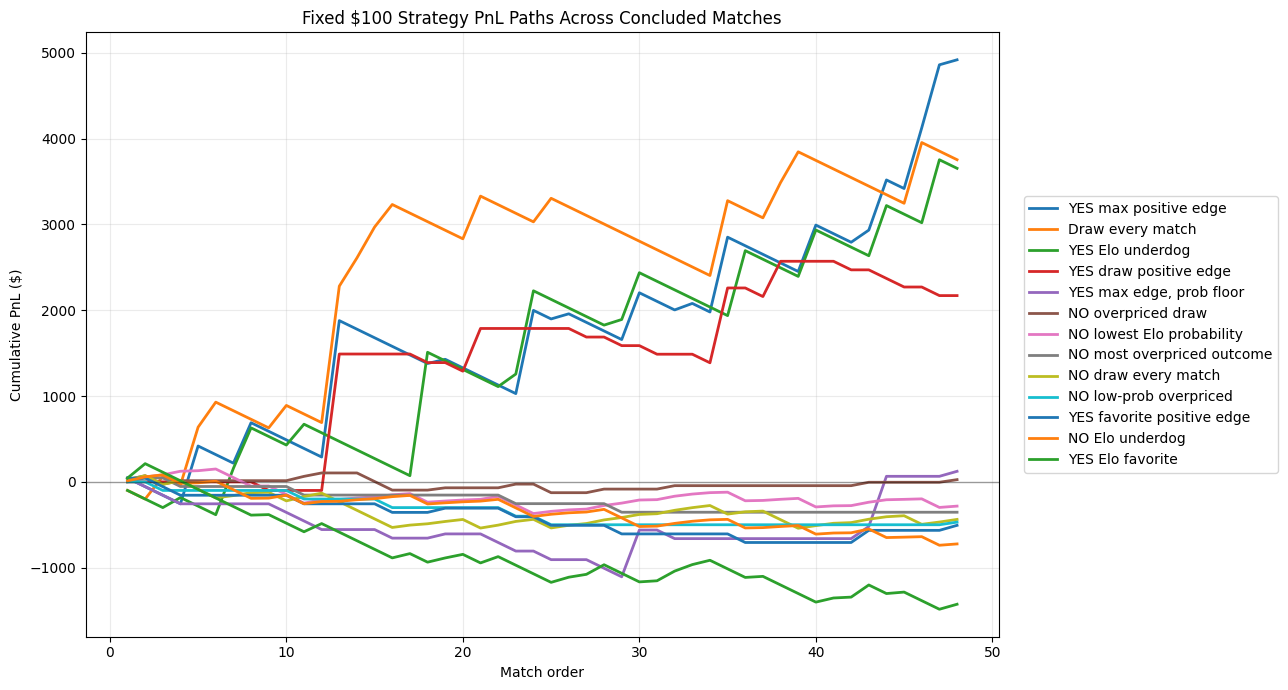

In [137]:
import matplotlib.pyplot as plt

pnl_paths = strategy_results.pivot_table(
    index="match_number",
    columns="strategy",
    values="cumulative_pnl",
    aggfunc="last",
).ffill().fillna(0)
pnl_paths.reset_index().to_csv(cache_path("world_cup_pnl_paths.csv"), index=False)

fig, ax = plt.subplots(figsize=(13, 7))
for strategy in strategy_summary.index:
    ax.plot(pnl_paths.index, pnl_paths[strategy], linewidth=2, label=strategy)

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.set_title(f"Fixed ${STAKE:,.0f} Strategy PnL Paths Across Concluded Matches")
ax.set_xlabel("Match order")
ax.set_ylabel("Cumulative PnL ($)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [138]:
strategy_results.sort_values(["match_number", "strategy"])[[
    "match_number",
    "event_title",
    "strategy",
    "selection",
    "actual_outcome",
    "bet_placed",
    "pnl",
    "cumulative_pnl",
]].head(80)

,match_number,event_title,strategy,selection,actual_outcome,bet_placed,pnl,cumulative_pnl
0,1,Mexico vs. South Africa,Draw every match,YES Draw,team1_win,True,-100.000000,-100.000000
432,1,Mexico vs. South Africa,NO Elo underdog,NO South Africa,team1_win,True,11.731844,11.731844
384,1,Mexico vs. South Africa,NO draw every match,NO Draw,team1_win,True,25.843325,25.843325
528,1,Mexico vs. South Africa,NO low-prob overpriced,None,team1_win,False,0.000000,0.000000
480,1,Mexico vs. South Africa,NO lowest Elo probability,NO South Africa,team1_win,True,11.731844,11.731844
336,1,Mexico vs. South Africa,NO most overpriced outcome,None,team1_win,False,0.000000,0.000000
576,1,Mexico vs. South Africa,NO overpriced draw,NO Draw,team1_win,True,25.843325,25.843325
96,1,Mexico vs. South Africa,YES Elo favorite,YES Mexico,team1_win,True,44.109523,44.109523
48,1,Mexico vs. South Africa,YES Elo underdog,YES South Africa,team1_win,True,-100.000000,-100.000000
288,1,Mexico vs. South Africa,YES draw positive edge,None,team1_win,False,0.000000,0.000000


## Notes / Things To Tune

- `BASE_DRAW_PROBABILITY_EQUAL_TEAMS` controls draw probability. The current default is `26%`; tune this with historical international data if you want calibrated draws.
- `HOME_ADVANTAGE_ELO` defaults to `0` because World Cup matches are mostly neutral-site, but co-host teams may deserve a positive adjustment.
- Elo TSV files refresh every run because they are cheap and change as new results arrive.
- Polymarket prices come only from the CLOB `prices-history` endpoint.
- `pre_match_yes_price` is the average implied YES price over `PRE_MATCH_PRICE_WINDOW_HOURS`. For completed matches, the window ends at kickoff. For upcoming matches, the window ends at current time.
- Completed Polymarket price-history windows are cached. Upcoming windows refresh each run because the current-time window changes.
- Only completed matches plus the next upcoming match day are included, so the notebook avoids downloading far-future fixture prices.
- The final cached CSV is written to `data/cache/football_elo_polymarket/world_cup_polymarket_elo_raw_table.csv`.